In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence, PatternedSequenceGenerator

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.spatial.distance import cosine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import torch.nn.functional as F
import random 
import pickle 

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # works only with NVIDIA GPUs (not on Mac)
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [3]:
def get_random_sequence(total_samples, token_number=7):
    return np.vectorize(chr)(np.random.randint(token_number, size=total_samples) + ord('A'))

In [4]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=1):
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), 1))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                self.X[ii,jj] = \
                ord(data[ii+jj])-65
      
            self.y[ii] = \
                ord(data[ii+jj+1])-65

        self.X = tnsr(self.X).long()
        self.y = tnsr(self.y).long()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [5]:
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, total_lags=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True, nonlinearity='tanh')

        self.linear = nn.ModuleDict({
            str(ii): nn.Linear(hidden_size, vocab_size) 
            for ii in range(total_lags)
        })
    
    def forward(self, x, h=None):
        embedded = self.embedding(x)                      # [batch, seq_len, emb_dim]
        out, h = self.rnn(embedded, h)                    # out: [batch, seq_len, hidden_size]
        
        last_hidden = out[:, -1, :]       # [batch, memory_unit]
        
        output_heads = {ii: head(last_hidden) 
                        for ii, head in self.linear.items()}
        
        return output_heads, h

In [6]:
def multihead_loss(output_heads, targets, criterion=None, reduction="mean"):
    """
    output_heads: dict[str, Tensor], each [batch, vocab_size]
    targets: list[Tensor] or dict[str, Tensor], each [batch]
    criterion: loss function, defaults to CrossEntropyLoss
    reduction: 'mean' or 'sum'
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    losses = []
    for key, pred in output_heads.items():
        # if targets is a list, assume order matches keys
        if isinstance(targets, dict):
            target = targets[key]
        else:
            target = targets[int(key)]   # cast string key to int if using list
        # print(pred, target)
        losses.append(criterion(pred[0], target))

    if reduction == "mean":
        return sum(losses) / len(losses)
    elif reduction == "sum":
        return sum(losses)
    else:
        return losses   # return list if you want per-head loss


In [ ]:
reps = 10
short_term_memories = [2, 4, 6, 8, 10, 12]
### initial training ###
total_samples = 100000
total_test_samples = 10000
working_memory = 1
# short_term_memory = 10
hidden_size = 50
vocab_size = 7
embedding_dim = 5
lr = 3e-3
res = {}
simulations = ['community', 'cyclic', 'hierarchical', 'markov', 'noisy', 'grammar']
total_sim = len(simulations)
sim_res = {}
tokens = []

grammar_rules = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F", "G"],
    "D": ["A", "F"],
    "E": ["C", "G"],
    "F": ["A", "E"],
    "G": ["B", "D"]
}

for ii in range(vocab_size):
    tokens.append(
        chr(ord('A')+ii)
    )

for sim in simulations:
        sim_res[sim] = {}

for short_term_memory in short_term_memories:
    print('Doing BPTT ', short_term_memory)

    for sim in simulations:
        sim_res[sim][short_term_memory] = []

    for rep in tqdm(range(reps)):
        model = RNNEncoder(vocab_size, embedding_dim, hidden_size, total_lags=short_term_memory)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-8)
        criterion = torch.nn.CrossEntropyLoss()

        data = get_random_sequence(total_samples, token_number=vocab_size)#get_sequence(total_samples, 2, 3, train_percent=1.0)

        data_set = Dataset_converter(data, working_memory, short_term_memory)
        train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

        total = 0
        test_acc = []
        correct = np.zeros(1000,dtype=float)
        for X, y in train_loader:
            optimizer.zero_grad()

            if total == 0:
                y_pred, h = model(X)
            else:
                y_pred, h = model(X, hidden)

            loss = multihead_loss(y_pred, X[0])     
            loss.backward()
            optimizer.step()

            # print(total)
            with torch.no_grad():
                hidden = h.detach()
                total += 1

                key = str(short_term_memory-1)
                if X[0][-1] == y_pred[key].argmax():
                        correct[total%1000] = 1
                else:
                    correct[total%1000] = 0
                
                if total%10000 == 0:
                    print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {np.sum(correct)/total if total<1000 else np.sum(correct)/1000:.4f}')

        for ii in tqdm(range(total_sim)):
            indx = 0
            generator = PatternedSequenceGenerator(tokens)

            if ii == 0:
                data = get_sequence(total_test_samples, (vocab_size-1)//3, 3, train_percent=1.0)
            elif ii == 1:
                data = generator.cyclic_sequence(cycle_length=vocab_size, total_length=total_test_samples)
            elif ii == 2:
                data = generator.hierarchical_sequence(outer_cycle=vocab_size, inner_cycle=vocab_size//2, total_length=total_test_samples)
            elif ii == 3:
                data = generator.markov_sequence(start_token="A", length=total_test_samples)
            elif ii == 4:
                cyclic_seq = generator.cyclic_sequence(cycle_length=vocab_size, total_length=total_test_samples)
                data = generator.noisy_sequence(cyclic_seq, noise_prob=0.2)
            elif ii == 5:
                data = generator.grammar_sequence(grammar_rules, start_token="A", length=total_test_samples)

            data_set = Dataset_converter(data, working_memory, short_term_memory)
            test_loader = DataLoader(data_set, batch_size=1, shuffle=False)

            correct_recon = np.zeros(short_term_memory, dtype=float)
            for X, y in test_loader:
                with torch.no_grad():

                    if indx == 0:
                        y_pred, h = model(X)
                    else:
                        y_pred, h = model(X, h)
                    indx += 1

                    for lag in range(short_term_memory):
                        key = str(lag)
                        if X[0][lag] == y_pred[key].argmax():
                                correct_recon[short_term_memory-lag-1] += 1
                        

            sim_res[simulations[ii]][short_term_memory].append(
                    list(correct_recon/len(data_set))
            )
            print(simulations[ii], " reconstruct accuracies ", sim_res[simulations[ii]][short_term_memory][-1])

            
with open('../pickle_files/ESN_memory_pretrain.pickle', 'wb') as f:
    pickle.dump(sim_res, f)

Doing BPTT  2


  0%|          | 0/10 [00:00<?, ?it/s]

Iter : 10001, loss: 0.0000, accuracy: 1.0000
Iter : 20001, loss: 0.0000, accuracy: 1.0000
Iter : 30001, loss: 0.0000, accuracy: 1.0000
Iter : 40001, loss: 0.0000, accuracy: 1.0000
Iter : 50001, loss: 0.0000, accuracy: 1.0000
Iter : 60001, loss: 0.0000, accuracy: 1.0000
Iter : 70001, loss: 0.0001, accuracy: 1.0000
Iter : 80001, loss: 0.0000, accuracy: 1.0000
Iter : 90001, loss: 0.0000, accuracy: 1.0000


community  reconstruct accuracies  [1.0, 1.0]


cyclic  reconstruct accuracies  [1.0, 1.0]


...

hierarchical  reconstruct accuracies  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


markov  reconstruct accuracies  [0.99989986983078, 0.99969960949234, 0.9994993491539, 0.9990988284770201, 0.9988985681385801, 0.9863822969860819, 0.9863822969860819, 0.9847802142785621, 0.9869830780014018, 0.9852808651246621, 0.9837789125863623, 0.978672273956143]


noisy  reconstruct accuracies  [1.0, 1.0, 0.99989986983078, 0.99979973966156, 0.9994993491539, 0.9977971362771603, 0.9970962250926204, 0.9854811254631021, 0.9666566536497446, 0.9943927105236808, 0.9971963552618404, 0.9982977871232602]


100%|██████████| 10/10 [24:10<00:00, 145.05s/it]

grammar  reconstruct accuracies  [1.0, 0.9989986983078002, 0.9991989586462401, 0.9981976569540403, 0.9990988284770201, 0.9948933613697807, 0.9968959647541804, 0.9953940122158806, 0.9954941423851006, 0.9917893261239612, 0.9943927105236808, 0.9921898468008411]


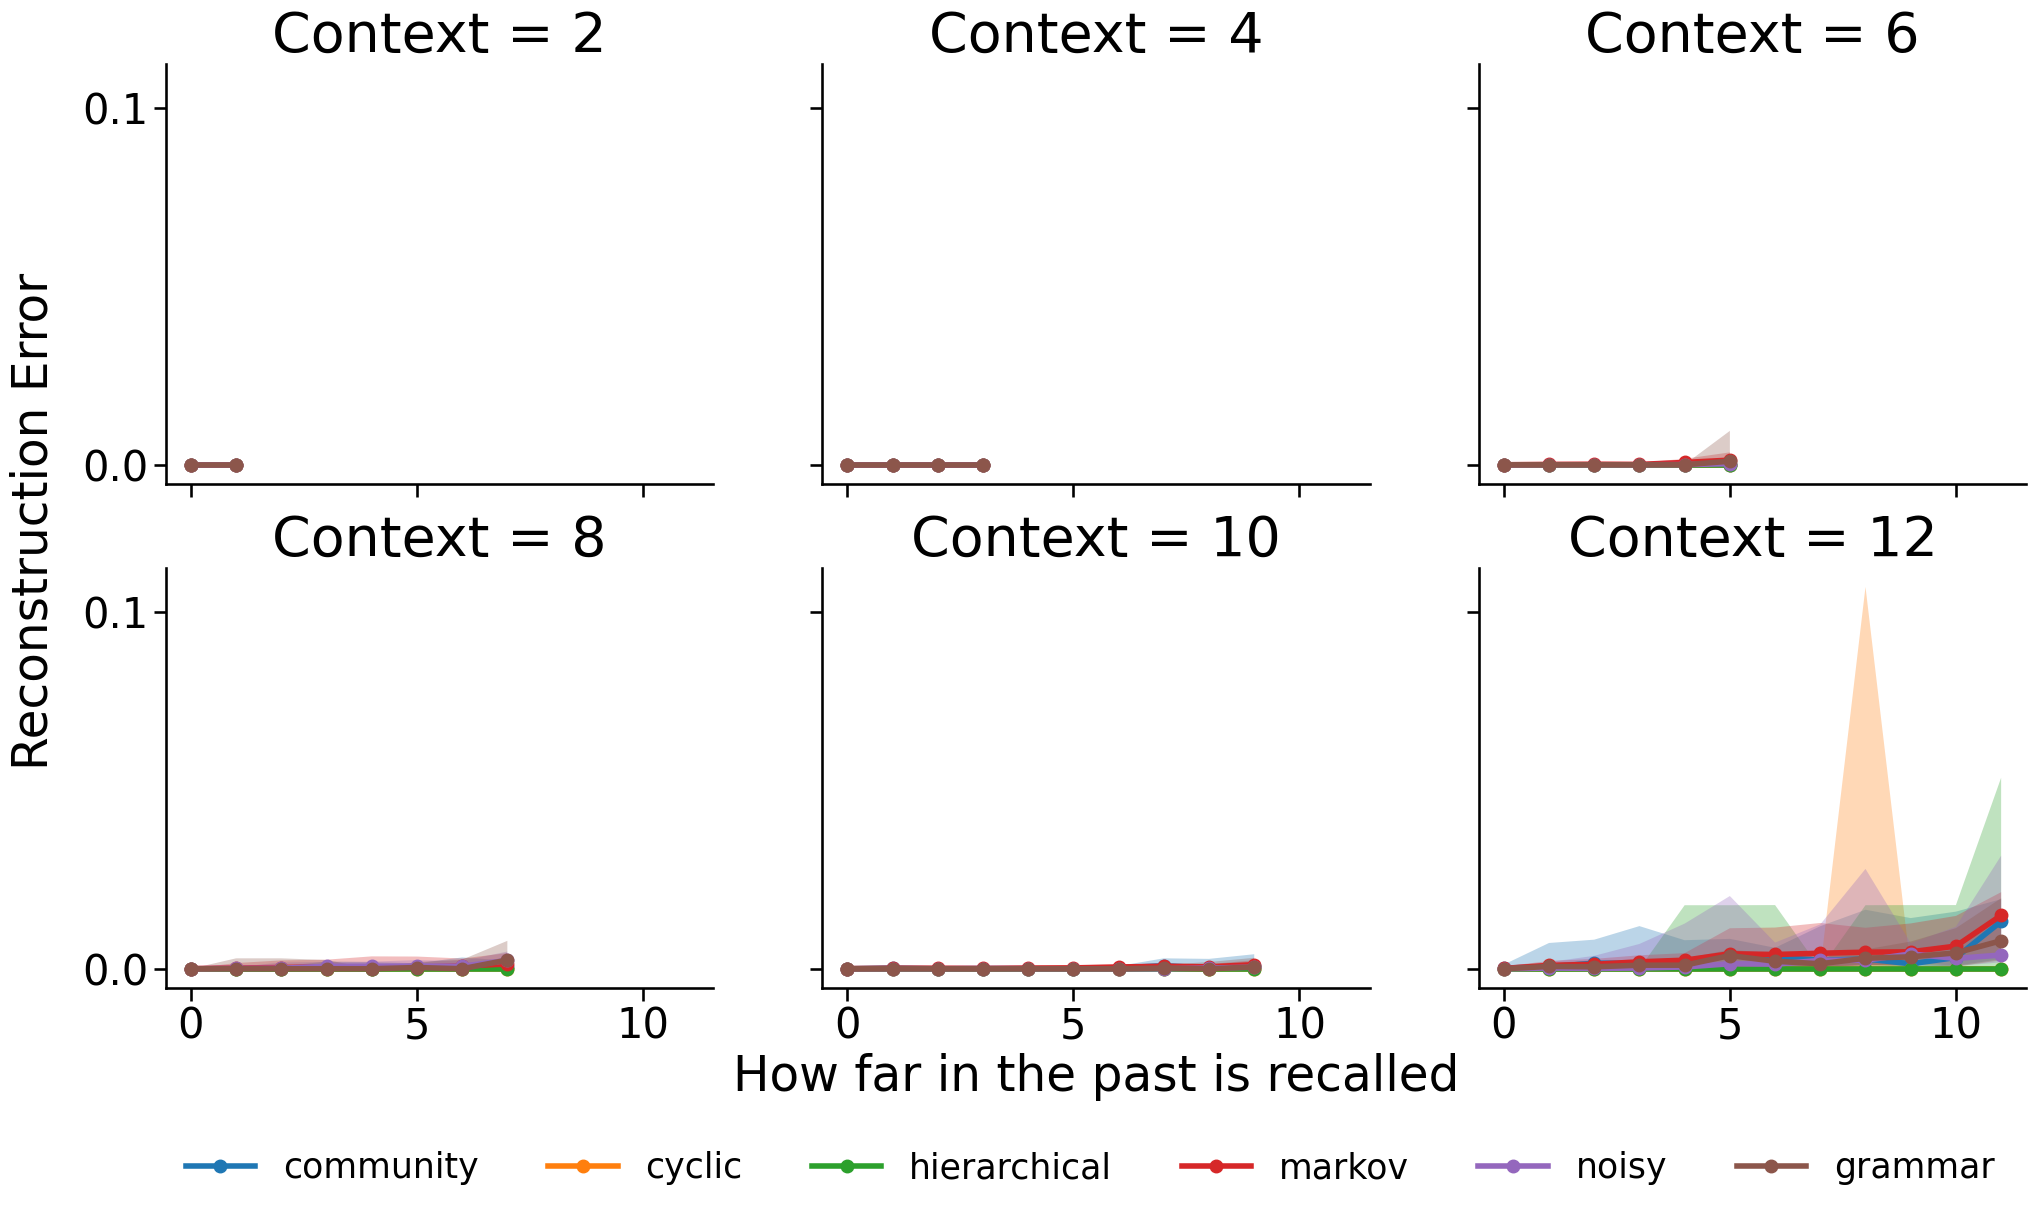

In [43]:
fig, ax = plt.subplots(2, 3, figsize=(24, 12), sharey=True, sharex=True)
sns.set_context('talk')
fontsize=40

for ii, context in enumerate(short_term_memories):
    row = ii//3
    col = ii%3
    for sim_name in simulations:
        res = 1 - np.array(sim_res[sim_name][context])

        if ii == 0:
            ax[row][col].plot(np.arange(context), np.median(res, axis=0), '-o', label=sim_name, linewidth=4)
        else:
            ax[row][col].plot(np.arange(context), np.median(res, axis=0), '-o', linewidth=4)

        ax[row][col].fill_between(np.arange(context), np.quantile(res, [0.25], axis=0)[0], np.quantile(res, [0.75], axis=0)[0], alpha=.3)

        right_side = ax[row][col].spines["right"]
        right_side.set_visible(False)
        top_side = ax[row][col].spines["top"]
        top_side.set_visible(False)

        ax[row][col].tick_params(labelsize=fontsize-10)
        ax[row][col].set_yticks([0,.1])
        ax[row][col].set_title('Context = '+str(context), fontsize=fontsize)
        
ax[1][1].set_xlabel('How far in the past is recalled', fontsize=fontsize-5)
fig.text(0.06,.3,'Reconstruction Error', fontsize=fontsize-5, rotation=90)

leg = fig.legend(bbox_to_anchor=(.9, 0), bbox_transform=plt.gcf().transFigure,
                        ncol=6, fontsize=25, frameon=False)

plt.savefig('../plots/memory_capacity_ESN_pretrained.pdf', bbox_inches='tight')